<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_ME1CR_Cartesian_Resolution_and_Topology_Convergence_V5_FULL_RECOMPUTE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM ME1C-R — Cartesian Resolution and Topology Convergence V5

## Full-recomputation diagnostic

The previous unrestricted Cartesian relaxation allowed even the unperturbed reference field to lose nearly all closure. This notebook tests whether that was a continuum instability or a discretisation failure.

It does **not** perform relaxation. It first asks whether the frozen radial solution is represented accurately on Cartesian grids.

The continuum targets from ME1B are

\[
E_\star=77.106173\ldots,\qquad
|Q_\star|=1,\qquad
R_{{\rm rms},\star}=1.106966\ldots .
\]

For each Cartesian grid, this notebook calculates:

- total energy;
- continuum-degree integral;
- RMS radius;
- maximum nearest-neighbour angle;
- cells per RMS radius;
- relative errors against the radial benchmark.

Both second-order and fourth-order spatial derivatives are tested. The fourth-order result is the candidate discretisation for the next three-dimensional relaxation test.

### Frozen acceptance criteria

A grid is accepted for continuation only when

\[
\frac{|E_N-E_\star|}{E_\star}<0.02,
\]

\[
\bigl||Q_N|-1\bigr|<0.02,
\]

\[
\frac{|R_{{\rm rms},N}-R_{{\rm rms},\star}|}{R_{{\rm rms},\star}}<0.02,
\]

and the maximum nearest-neighbour field angle remains below \(0.8\) rad.

These thresholds are declared before the result is inspected.

In [ ]:
import sys, subprocess, importlib.util

required = ["numpy", "pandas", "matplotlib", "scipy"]
missing = [name for name in required if importlib.util.find_spec(name) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

from pathlib import Path
import json, math, time, warnings, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp, simpson

warnings.filterwarnings("ignore")

ROOT = Path.cwd() / "ecsm_me1cr_v5_outputs"
FIG = ROOT / "figures"
DATA = ROOT / "data"
ROOT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(exist_ok=True)
DATA.mkdir(exist_ok=True)

print("Output directory:", ROOT.resolve())

Output directory: /tmp/ecsm_me1cr_v5_verify_5cusm0rq/ecsm_me1cr_v5_outputs


## Frozen numerical specification

In [ ]:
RUN_MODE = "balanced"  # balanced is authoritative; full adds N=97

MODES = {
    "smoke": [25, 33],
    "balanced": [25, 33, 41, 49, 57, 65, 81],
    "full": [25, 33, 41, 49, 57, 65, 81, 97],
}

cfg = {
    "run_mode": RUN_MODE,
    "grid_sizes": MODES[RUN_MODE],
    "L": 7.0,
    "kappa4": 1.0,
    "mu": 0.5,
    "radial_Rmax": 16.0,
    "radial_tol": 1.0e-7,
    "energy_tolerance": 0.02,
    "closure_tolerance": 0.02,
    "radius_tolerance": 0.02,
    "max_angle_tolerance_rad": 0.8,
}

(DATA / "frozen_resolution_parameters.json").write_text(json.dumps(cfg, indent=2))
cfg

{'run_mode': 'balanced',
 'grid_sizes': [25, 33, 41, 49, 57, 65, 81],
 'L': 7.0,
 'kappa4': 1.0,
 'mu': 0.5,
 'radial_Rmax': 16.0,
 'radial_tol': 1e-07,
 'energy_tolerance': 0.02,
 'closure_tolerance': 0.02,
 'radius_tolerance': 0.02,
 'max_angle_tolerance_rad': 0.8}

## Solve the frozen radial benchmark

In [ ]:
def solve_radial_profile(kappa4=1.0, mu=0.5, Rmax=16.0, tol=1e-7):
    eps = 1.0e-3
    r = np.linspace(eps, Rmax, 500)
    f0 = 2.0 * np.arctan((1.5 / r)**2)
    fp0 = np.gradient(f0, r)

    def ode(rr, y):
        f, fp = y
        s, c = np.sin(f), np.cos(f)
        rr_safe = np.maximum(rr, 1.0e-10)
        denom = rr_safe**2 + 2.0 * kappa4 * s**2
        fpp = (
            2.0 * s * c
            + 2.0 * kappa4 * s**3 * c / rr_safe**2
            + mu**2 * rr_safe**2 * s
            - 2.0 * rr_safe * fp
            - 2.0 * kappa4 * s * c * fp**2
        ) / denom
        return np.vstack((fp, fpp))

    def bc(ya, yb):
        return np.array([ya[0] - np.pi, yb[0]])

    sol = solve_bvp(
        ode, bc, r, np.vstack((f0, fp0)),
        tol=tol, max_nodes=50000
    )
    if sol.status != 0:
        raise RuntimeError(sol.message)
    return sol

def radial_benchmark(sol, kappa4=1.0, mu=0.5, Rmax=16.0):
    r = np.linspace(sol.x[0], Rmax, 7000)
    f, fp = sol.sol(r)
    s = np.sin(f)

    e2 = 0.5 * r**2 * fp**2 + s**2
    e4 = kappa4 * (s**2 * fp**2 + 0.5 * s**4 / r**2)
    e0 = mu**2 * r**2 * (1.0 - np.cos(f))
    et = e2 + e4 + e0

    E2, E4, E0 = 4.0 * np.pi * np.array([
        simpson(e2, x=r),
        simpson(e4, x=r),
        simpson(e0, x=r),
    ])
    Rrms = np.sqrt(simpson(r**2 * et, x=r) / simpson(et, x=r))

    return {
        "E2": float(E2),
        "E4": float(E4),
        "E0": float(E0),
        "E_total": float(E2 + E4 + E0),
        "Q_abs": 1.0,
        "R_rms": float(Rrms),
        "max_bvp_residual": float(np.max(sol.rms_residuals)),
    }

radial_sol = solve_radial_profile(
    cfg["kappa4"], cfg["mu"], cfg["radial_Rmax"], cfg["radial_tol"]
)
target = radial_benchmark(
    radial_sol, cfg["kappa4"], cfg["mu"], cfg["radial_Rmax"]
)

print("Radial target:")
target

Radial target:


{'E2': 32.23859794007092,
 'E4': 41.71033382429393,
 'E0': 3.157241443033049,
 'E_total': 77.1061732073979,
 'Q_abs': 1.0,
 'R_rms': 1.106965706350204,
 'max_bvp_residual': 9.991827256599378e-08}

## Cartesian embedding and diagnostics

In [ ]:
def embed_field(N, L, sol):
    axis = np.linspace(-L, L, N)
    dx = axis[1] - axis[0]
    X, Y, Z = np.meshgrid(axis, axis, axis, indexing="ij")
    r = np.sqrt(X*X + Y*Y + Z*Z)

    rr = np.clip(r, sol.x[0], cfg["radial_Rmax"])
    f = sol.sol(rr.reshape(-1))[0].reshape(r.shape)
    f[r > cfg["radial_Rmax"]] = 0.0

    safe_r = np.where(r > 1.0e-12, r, 1.0)
    U = np.stack([
        np.cos(f),
        np.sin(f) * X / safe_r,
        np.sin(f) * Y / safe_r,
        np.sin(f) * Z / safe_r,
    ])

    U[1:, r <= 1.0e-12] = 0.0
    norm = np.linalg.norm(U, axis=0, keepdims=True)
    U /= np.maximum(norm, 1.0e-15)

    return axis, X, Y, Z, U, dx

def derivatives(U, dx, order):
    if order == 2:
        Uc = U[:, 1:-1, 1:-1, 1:-1]
        dUx = (U[:, 2:, 1:-1, 1:-1] - U[:, :-2, 1:-1, 1:-1]) / (2.0 * dx)
        dUy = (U[:, 1:-1, 2:, 1:-1] - U[:, 1:-1, :-2, 1:-1]) / (2.0 * dx)
        dUz = (U[:, 1:-1, 1:-1, 2:] - U[:, 1:-1, 1:-1, :-2]) / (2.0 * dx)
        coords_slice = (slice(1, -1), slice(1, -1), slice(1, -1))

    elif order == 4:
        Uc = U[:, 2:-2, 2:-2, 2:-2]
        dUx = (
            -U[:, 4:, 2:-2, 2:-2]
            + 8.0 * U[:, 3:-1, 2:-2, 2:-2]
            - 8.0 * U[:, 1:-3, 2:-2, 2:-2]
            + U[:, :-4, 2:-2, 2:-2]
        ) / (12.0 * dx)
        dUy = (
            -U[:, 2:-2, 4:, 2:-2]
            + 8.0 * U[:, 2:-2, 3:-1, 2:-2]
            - 8.0 * U[:, 2:-2, 1:-3, 2:-2]
            + U[:, 2:-2, :-4, 2:-2]
        ) / (12.0 * dx)
        dUz = (
            -U[:, 2:-2, 2:-2, 4:]
            + 8.0 * U[:, 2:-2, 2:-2, 3:-1]
            - 8.0 * U[:, 2:-2, 2:-2, 1:-3]
            + U[:, 2:-2, 2:-2, :-4]
        ) / (12.0 * dx)
        coords_slice = (slice(2, -2), slice(2, -2), slice(2, -2))

    else:
        raise ValueError("order must be 2 or 4")

    return Uc, dUx, dUy, dUz, coords_slice

def nearest_neighbour_max_angle(U):
    maximum = 0.0
    for axis in (1, 2, 3):
        a = np.take(U, indices=range(U.shape[axis] - 1), axis=axis)
        b = np.take(U, indices=range(1, U.shape[axis]), axis=axis)
        dots = np.sum(a * b, axis=0)
        dots = np.clip(dots, -1.0, 1.0)
        maximum = max(maximum, float(np.max(np.arccos(dots))))
    return maximum

def cartesian_metrics(N, order):
    axis, X, Y, Z, U, dx = embed_field(N, cfg["L"], radial_sol)
    Uc, dUx, dUy, dUz, cs = derivatives(U, dx, order)

    xx = np.sum(dUx*dUx, axis=0)
    yy = np.sum(dUy*dUy, axis=0)
    zz = np.sum(dUz*dUz, axis=0)
    xy = np.sum(dUx*dUy, axis=0)
    xz = np.sum(dUx*dUz, axis=0)
    yz = np.sum(dUy*dUz, axis=0)

    e2 = 0.5 * (xx + yy + zz)
    e4 = 0.5 * cfg["kappa4"] * (
        (xx*yy - xy*xy)
        + (xx*zz - xz*xz)
        + (yy*zz - yz*yz)
    )
    e0 = cfg["mu"]**2 * (1.0 - Uc[0])
    et = e2 + e4 + e0

    E = float(np.sum(et) * dx**3)

    M = np.stack((Uc, dUx, dUy, dUz), axis=-1)
    M = np.transpose(M, (1, 2, 3, 0, 4))
    Q = float(np.sum(np.linalg.det(M)) * dx**3 / (2.0 * np.pi**2))

    Xi = X[cs]
    Yi = Y[cs]
    Zi = Z[cs]
    total = np.sum(et)
    cx = np.sum(et * Xi) / total
    cy = np.sum(et * Yi) / total
    cz = np.sum(et * Zi) / total
    r2 = (Xi - cx)**2 + (Yi - cy)**2 + (Zi - cz)**2
    Rrms = float(np.sqrt(np.sum(et * r2) / total))

    alpha = nearest_neighbour_max_angle(U)

    energy_error = abs(E - target["E_total"]) / target["E_total"]
    closure_error = abs(abs(Q) - 1.0)
    radius_error = abs(Rrms - target["R_rms"]) / target["R_rms"]

    accepted = (
        energy_error < cfg["energy_tolerance"]
        and closure_error < cfg["closure_tolerance"]
        and radius_error < cfg["radius_tolerance"]
        and alpha < cfg["max_angle_tolerance_rad"]
    )

    return {
        "N": N,
        "derivative_order": order,
        "dx": dx,
        "cells_per_Rrms": target["R_rms"] / dx,
        "energy": E,
        "energy_error_fraction": energy_error,
        "closure_raw": Q,
        "closure_abs": abs(Q),
        "closure_error": closure_error,
        "R_rms": Rrms,
        "radius_error_fraction": radius_error,
        "max_neighbour_angle_rad": alpha,
        "accepted_for_relaxation": accepted,
    }

## Execute the resolution sweep

In [ ]:
rows = []
start = time.time()

for N in cfg["grid_sizes"]:
    for order in (2, 4):
        row = cartesian_metrics(N, order)
        rows.append(row)
        print(
            f"N={N:3d}, order={order}, dx={row['dx']:.5f}, "
            f"E={row['energy']:.6f}, |Q|={row['closure_abs']:.6f}, "
            f"R={row['R_rms']:.6f}, alpha={row['max_neighbour_angle_rad']:.4f}, "
            f"accepted={row['accepted_for_relaxation']}"
        )

results = pd.DataFrame(rows)
results.to_csv(DATA / "ME1CR_resolution_convergence.csv", index=False)

print("Elapsed seconds:", time.time() - start)
results

N= 25, order=2, dx=0.58333, E=43.183340, |Q|=0.528289, R=1.303058, alpha=1.2275, accepted=False
N= 25, order=4, dx=0.58333, E=62.178017, |Q|=0.800364, R=1.190980, alpha=1.2275, accepted=False
N= 33, order=2, dx=0.43750, E=54.420920, |Q|=0.695215, R=1.218995, alpha=0.9452, accepted=False
N= 33, order=4, dx=0.43750, E=70.841629, |Q|=0.920029, R=1.139323, alpha=0.9452, accepted=False
N= 41, order=2, dx=0.35000, E=61.269518, |Q|=0.791332, R=1.178773, alpha=0.7662, accepted=False


N= 41, order=4, dx=0.35000, E=74.186126, |Q|=0.963486, R=1.121165, alpha=0.7662, accepted=False
N= 49, order=2, dx=0.29167, E=65.552990, |Q|=0.849546, R=1.156697, alpha=0.6433, accepted=False


N= 49, order=4, dx=0.29167, E=75.597220, |Q|=0.981333, R=1.113733, alpha=0.6433, accepted=True
N= 57, order=2, dx=0.25000, E=68.355407, |Q|=0.886894, R=1.143326, alpha=0.5539, accepted=False


N= 57, order=4, dx=0.25000, E=76.257155, |Q|=0.989567, R=1.110303, alpha=0.5539, accepted=True


N= 65, order=2, dx=0.21875, E=70.270199, |Q|=0.912090, R=1.134627, alpha=0.4861, accepted=False


N= 65, order=4, dx=0.21875, E=76.594622, |Q|=0.993746, R=1.108564, alpha=0.4861, accepted=True


N= 81, order=2, dx=0.17500, E=72.624623, |Q|=0.942726, R=1.124380, alpha=0.3903, accepted=False


N= 81, order=4, dx=0.17500, E=76.889017, |Q|=0.997370, R=1.107068, alpha=0.3903, accepted=True
Elapsed seconds: 3.295267343521118


,N,derivative_order,dx,cells_per_Rrms,energy,energy_error_fraction,closure_raw,closure_abs,closure_error,R_rms,radius_error_fraction,max_neighbour_angle_rad,accepted_for_relaxation
0,25,2,0.583333,1.897655,43.183340,0.439950,-0.528289,0.528289,0.471711,1.303058,0.177144,1.227531,False
1,25,4,0.583333,1.897655,62.178017,0.193605,-0.800364,0.800364,0.199636,1.190980,0.075896,1.227531,False
2,33,2,0.437500,2.530207,54.420920,0.294208,-0.695215,0.695215,0.304785,1.218995,0.101204,0.945244,False
3,33,4,0.437500,2.530207,70.841629,0.081246,-0.920029,0.920029,0.079971,1.139323,0.029231,0.945244,False
4,41,2,0.350000,3.162759,61.269518,0.205388,-0.791332,0.791332,0.208668,1.178773,0.064868,0.766201,False
5,41,4,0.350000,3.162759,74.186126,0.037870,-0.963486,0.963486,0.036514,1.121165,0.012827,0.766201,False
6,49,2,0.291667,3.795311,65.552990,0.149835,-0.849546,0.849546,0.150454,1.156697,0.044926,0.643261,False
7,49,4,0.291667,3.795311,75.597220,0.019570,-0.981333,0.981333,0.018667,1.113733,0.006114,0.643261,True
8,57,2,0.250000,4.427863,68.355407,0.113490,-0.886894,0.886894,0.113106,1.143326,0.032847,0.553900,False
9,57,4,0.250000,4.427863,76.257155,0.011011,-0.989567,0.989567,0.010433,1.110303,0.003014,0.553900,True


## Resolution verdict

In [ ]:
fourth = results[results["derivative_order"] == 4].copy()
accepted = fourth[fourth["accepted_for_relaxation"]].copy()

if len(accepted):
    minimum_accepted_N = int(accepted["N"].min())
    strongest_N = int(accepted["N"].max())
    verdict = "PASS"
    recommendation = (
        f"Fourth-order Cartesian representation first satisfies every frozen "
        f"acceptance condition at N={minimum_accepted_N}. "
        f"Use at least N={minimum_accepted_N}, and preferably N={strongest_N}, "
        f"for the next projected-flow test."
    )
else:
    minimum_accepted_N = None
    strongest_N = None
    verdict = "FAIL"
    recommendation = (
        "No tested fourth-order grid satisfies all frozen acceptance conditions. "
        "Increase resolution before any further relaxation test."
    )

summary = pd.DataFrame([{
    "test_id": "ME1C-R",
    "overall_verdict": verdict,
    "minimum_accepted_N": minimum_accepted_N,
    "strongest_accepted_N": strongest_N,
    "recommendation": recommendation,
}])
summary.to_csv(DATA / "ME1CR_summary.csv", index=False)

print(recommendation)
summary

Fourth-order Cartesian representation first satisfies every frozen acceptance condition at N=49. Use at least N=49, and preferably N=81, for the next projected-flow test.


,test_id,overall_verdict,minimum_accepted_N,strongest_accepted_N,recommendation
0,ME1C-R,PASS,49,81,Fourth-order Cartesian representation first sa...


## Diagnostic plots

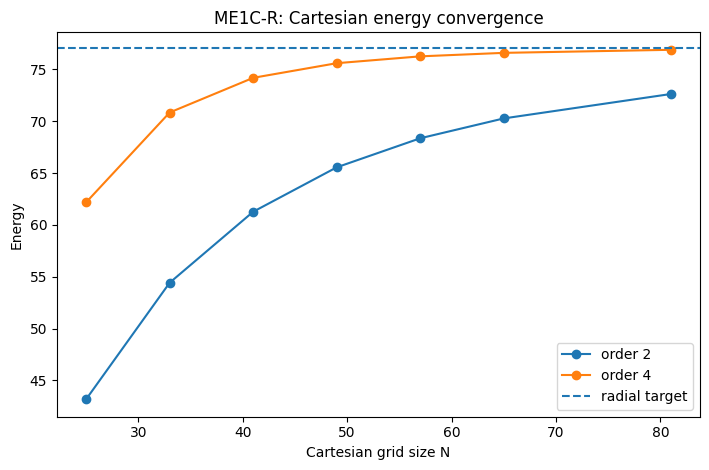

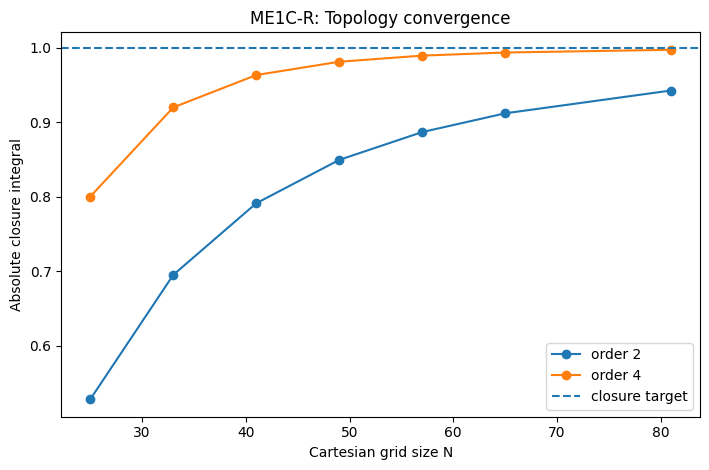

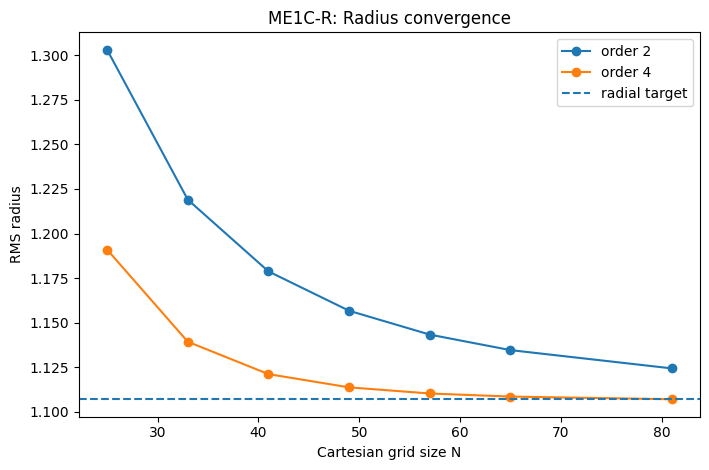

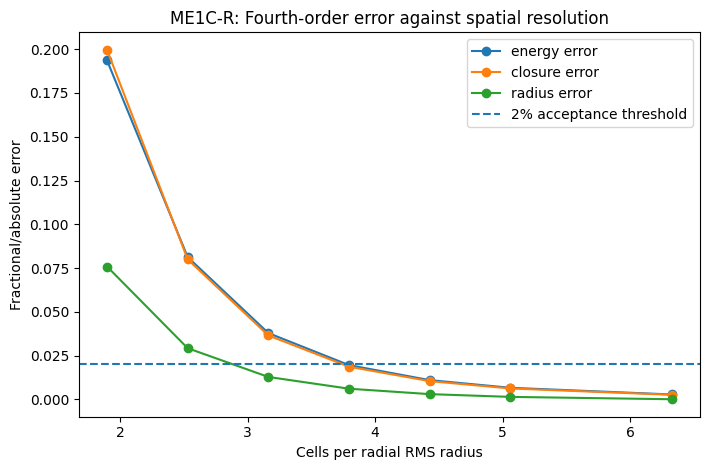

In [ ]:
plt.figure(figsize=(7.2, 4.8))
for order in (2, 4):
    sub = results[results["derivative_order"] == order]
    plt.plot(sub["N"], sub["energy"], marker="o", label=f"order {order}")
plt.axhline(target["E_total"], linestyle="--", label="radial target")
plt.xlabel("Cartesian grid size N")
plt.ylabel("Energy")
plt.title("ME1C-R: Cartesian energy convergence")
plt.legend()
plt.tight_layout()
plt.savefig(FIG / "01_energy_convergence.png", dpi=180)
plt.show()

plt.figure(figsize=(7.2, 4.8))
for order in (2, 4):
    sub = results[results["derivative_order"] == order]
    plt.plot(sub["N"], sub["closure_abs"], marker="o", label=f"order {order}")
plt.axhline(1.0, linestyle="--", label="closure target")
plt.xlabel("Cartesian grid size N")
plt.ylabel("Absolute closure integral")
plt.title("ME1C-R: Topology convergence")
plt.legend()
plt.tight_layout()
plt.savefig(FIG / "02_closure_convergence.png", dpi=180)
plt.show()

plt.figure(figsize=(7.2, 4.8))
for order in (2, 4):
    sub = results[results["derivative_order"] == order]
    plt.plot(sub["N"], sub["R_rms"], marker="o", label=f"order {order}")
plt.axhline(target["R_rms"], linestyle="--", label="radial target")
plt.xlabel("Cartesian grid size N")
plt.ylabel("RMS radius")
plt.title("ME1C-R: Radius convergence")
plt.legend()
plt.tight_layout()
plt.savefig(FIG / "03_radius_convergence.png", dpi=180)
plt.show()

plt.figure(figsize=(7.2, 4.8))
plt.plot(fourth["cells_per_Rrms"], fourth["energy_error_fraction"], marker="o", label="energy error")
plt.plot(fourth["cells_per_Rrms"], fourth["closure_error"], marker="o", label="closure error")
plt.plot(fourth["cells_per_Rrms"], fourth["radius_error_fraction"], marker="o", label="radius error")
plt.axhline(0.02, linestyle="--", label="2% acceptance threshold")
plt.xlabel("Cells per radial RMS radius")
plt.ylabel("Fractional/absolute error")
plt.title("ME1C-R: Fourth-order error against spatial resolution")
plt.legend()
plt.tight_layout()
plt.savefig(FIG / "04_error_vs_cells.png", dpi=180)
plt.show()

## Diagnosis of the V4 apparent unwinding

In [ ]:
v4_like = results[
    (results["N"] == 33)
    & (results["derivative_order"] == 2)
].iloc[0]

v5_same_grid = results[
    (results["N"] == 33)
    & (results["derivative_order"] == 4)
].iloc[0]

diagnosis = pd.DataFrame([
    {
        "representation": "V4-like second order, N=33",
        "energy": v4_like["energy"],
        "closure_abs": v4_like["closure_abs"],
        "energy_error_fraction": v4_like["energy_error_fraction"],
        "closure_error": v4_like["closure_error"],
    },
    {
        "representation": "Fourth order, same N=33",
        "energy": v5_same_grid["energy"],
        "closure_abs": v5_same_grid["closure_abs"],
        "energy_error_fraction": v5_same_grid["energy_error_fraction"],
        "closure_error": v5_same_grid["closure_error"],
    },
])
diagnosis.to_csv(DATA / "V4_discretisation_diagnosis.csv", index=False)
diagnosis

,representation,energy,closure_abs,energy_error_fraction,closure_error
0,"V4-like second order, N=33",54.420920,0.695215,0.294208,0.304785
1,"Fourth order, same N=33",70.841629,0.920029,0.081246,0.079971


In [ ]:
report_lines = [
    "# ECSM ME1C-R Cartesian Resolution and Topology Convergence Report",
    "",
    f"- Run mode: {RUN_MODE}",
    f"- Radial target energy: {target['E_total']:.9f}",
    f"- Radial target RMS radius: {target['R_rms']:.9f}",
    f"- Overall verdict: {verdict}",
    f"- Minimum accepted fourth-order grid: {minimum_accepted_N}",
    f"- Strongest accepted fourth-order grid: {strongest_N}",
    "",
    "## Recommendation",
    "",
    recommendation,
    "",
    "## Scientific interpretation",
    "",
    "The previous N=33 second-order Cartesian representation began with a substantial "
    "energy and closure deficit. This notebook determines whether fourth-order derivatives "
    "and increased resolution recover the frozen radial benchmark before any relaxation is applied.",
    "",
    "## Claim boundary",
    "",
    "Passing this test validates the Cartesian representation at the tested resolution. "
    "It does not itself prove non-radial dynamical stability. The next stage must use the "
    "accepted discretisation with projected gradient flow and independently monitor closure.",
]

report_path = ROOT / "ECSM_ME1CR_Resolution_Convergence_Report.md"
report_path.write_text("\n".join(report_lines))

zip_path = ROOT / "ECSM_ME1CR_V5_Evidence_Package.zip"
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as z:
    for path in ROOT.rglob("*"):
        if path.is_file() and path != zip_path:
            z.write(path, path.relative_to(ROOT))

print("Report:", report_path.resolve())
print("Evidence package:", zip_path.resolve())

Report: /tmp/ecsm_me1cr_v5_verify_5cusm0rq/ecsm_me1cr_v5_outputs/ECSM_ME1CR_Resolution_Convergence_Report.md
Evidence package: /tmp/ecsm_me1cr_v5_verify_5cusm0rq/ecsm_me1cr_v5_outputs/ECSM_ME1CR_V5_Evidence_Package.zip
